In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

from scipy.stats import linregress

plt.style.use("ggplot")

In [3]:
nav = pd.read_csv("../data/processed/nav_history_clean.csv")

performance = pd.read_csv("../data/processed/scheme_performance_clean.csv")

benchmark = pd.read_csv("../data/processed/benchmark_indices_clean.csv")

fund = pd.read_csv("../data/processed/fund_master_clean.csv")

In [ ]:

nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(["amfi_code","date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


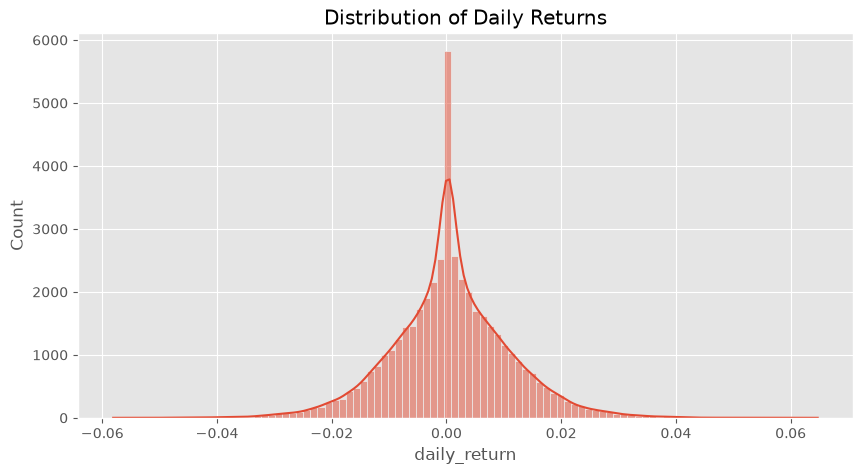

In [5]:
plt.figure(figsize=(10,5))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=100,
    kde=True
)

plt.title("Distribution of Daily Returns")

plt.show()

In [6]:
def CAGR(start,end,years):
    return ((end/start)**(1/years))-1

In [ ]:
records=[]

for code,df in nav.groupby("amfi_code"):

    df=df.sort_values("date")

    start=df.iloc[0]["nav"]

    end=df.iloc[-1]["nav"]

    years=(df["date"].max()-df["date"].min()).days/365

    cagr=CAGR(start,end,years)

    records.append([code,cagr])

cagr_df=pd.DataFrame(
    records,
    columns=["amfi_code","CAGR"]
)

cagr_df.head()                                                                                                  

,amfi_code,CAGR
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331


In [8]:
RF=0.065

records=[]

for code,df in nav.groupby("amfi_code"):

    r=df["daily_return"].dropna()

    sharpe=((r.mean()*252)-RF)/(r.std()*np.sqrt(252))

    records.append([code,sharpe])

sharpe_df=pd.DataFrame(
    records,
    columns=["amfi_code","Sharpe"]
)

sharpe_df=sharpe_df.sort_values(
    "Sharpe",
    ascending=False
)

sharpe_df.head()

,amfi_code,Sharpe
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101


In [ ]:
records=[]

for code,df in nav.groupby("amfi_code"):

    r=df["daily_return"].dropna()

    downside=r[r<0]

    sortino=((r.mean()*252)-RF)/(downside.std()*np.sqrt(252))

    records.append([code,sortino])

sortino_df=pd.DataFrame(
    records,
    columns=["amfi_code","Sortino"]
)

sortino_df.head()                   

,amfi_code,Sortino
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [15]:
benchmark["date"]=pd.to_datetime(
    benchmark["date"]
)

benchmark["benchmark_return"]=benchmark[
    "close_value"
].pct_change()                                          

In [13]:
print(benchmark.columns.tolist())

['date', 'index_name', 'close_value']


In [16]:
records=[]

for code,df in nav.groupby("amfi_code"):

    temp=df.merge(
        benchmark[["date","benchmark_return"]],
        on="date"
    )

    temp=temp.dropna()

    beta,alpha,r,p,se=linregress(
        temp["benchmark_return"],
        temp["daily_return"]
    )

    alpha=alpha*252

    records.append([
        code,
        alpha,
        beta
    ])

alpha_beta=pd.DataFrame(
    records,
    columns=[
        "amfi_code",
        "Alpha",
        "Beta"
    ]
)

alpha_beta.head()

,amfi_code,Alpha,Beta
0,100016,0.035008,0.004843
1,100025,0.043330,-0.003422
2,100033,0.268752,0.024097
3,101206,0.214656,-0.000067
4,101207,0.110250,-0.023588


In [17]:
alpha_beta.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)            

In [18]:
records=[]

for code,df in nav.groupby("amfi_code"):

    running_max=df["nav"].cummax()

    drawdown=df["nav"]/running_max-1

    records.append([
        code,
        drawdown.min()
    ])

drawdown_df=pd.DataFrame(
    records,
    columns=[
        "amfi_code",
        "Max_Drawdown"
    ]
)

drawdown_df.head()

,amfi_code,Max_Drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [21]:
score=cagr_df.merge(
    sharpe_df,
    on="amfi_code"
)

score=score.merge(
    alpha_beta,
    on="amfi_code"
)

score=score.merge(
    drawdown_df,
    on="amfi_code"
)

score=score.merge(
    performance[
        ["amfi_code","expense_ratio_pct"]
    ],
    on="amfi_code"
)

In [20]:
print(performance.columns.tolist())

['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


In [23]:
score["ReturnRank"]=score[
    "CAGR"
].rank()

score["SharpeRank"]=score[
    "Sharpe"
].rank()

score["AlphaRank"]=score[
    "Alpha"
].rank()

score["ExpenseRank"]=(
    score["expense_ratio_pct"]
    .rank(ascending=False)
)

score["DrawdownRank"]=(
    score["Max_Drawdown"]
    .rank(ascending=False)
)

In [24]:
score["FundScore"]=(
0.30*score["ReturnRank"]+
0.25*score["SharpeRank"]+
0.20*score["AlphaRank"]+
0.15*score["ExpenseRank"]+
0.10*score["DrawdownRank"]
)

score=score.sort_values(
    "FundScore",
    ascending=False
)

score.head()

,amfi_code,CAGR,Sharpe,Alpha,Beta,Max_Drawdown,expense_ratio_pct,ReturnRank,SharpeRank,AlphaRank,ExpenseRank,DrawdownRank,FundScore
25,120505,0.328016,1.180101,0.295085,-0.017454,-0.181885,1.36,40.0,36.0,38.0,26.0,25.0,35.000
21,119598,0.323981,0.945308,0.303145,-0.003508,-0.287060,1.43,39.0,27.0,40.0,20.0,36.0,33.050
39,149324,0.322621,0.949796,0.295821,0.036667,-0.311719,1.52,38.0,28.0,39.0,14.5,37.0,32.075
30,120843,0.308833,1.306744,0.273211,-0.004370,-0.129740,1.45,35.0,39.0,36.0,19.0,13.0,31.600
34,148567,0.309499,1.448291,0.269107,0.010472,-0.112657,1.46,36.0,40.0,35.0,18.0,8.0,31.300


In [25]:
score.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)


In [27]:
fund = pd.read_csv("../data/processed/fund_master_clean.csv")

print(fund.columns.tolist())

['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']


In [28]:
nav = nav.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

In [29]:
top5=score.head()["amfi_code"]
plot_df=nav[
    nav["amfi_code"].isin(top5)
]
fig=px.line(
    plot_df,
    x="date",
    y="nav",
    color="scheme_name",
    title="Top 5 Funds vs Benchmark"
)

fig.show()
fig.write_image(
"../charts/benchmark_comparison.png"
)

In [30]:
records=[]

for code,df in nav.groupby("amfi_code"):

    temp=df.merge(
        benchmark[
            ["date","benchmark_return"]
        ],
        on="date"
    )

    temp=temp.dropna()

    tracking=(
        temp["daily_return"]-
        temp["benchmark_return"]
    ).std()*np.sqrt(252)

    records.append([
        code,
        tracking
    ])

tracking_error=pd.DataFrame(
    records,
    columns=[
        "amfi_code",
        "Tracking_Error"
    ]
)

tracking_error.head()

,amfi_code,Tracking_Error
0,100016,0.200661
1,100025,0.144771
2,100033,0.232821
3,101206,0.201278
4,101207,0.294472
